In [2]:
# =========================================================
# NOTEBOOK: 13_lstm_forecasting.ipynb
# =========================================================

# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import warnings

warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# =========================================================
# STEP 2 — LOAD DATASET
# =========================================================

master_df = pd.read_csv(
    r"C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\processed\statistical_analysis_dataset.csv"
)

print(master_df.shape)

master_df.head()

(2530433, 87)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration_days,delivery_delay_days,...,Monetary,churn,product_revenue,product_total_orders,product_avg_review,product_avg_delay,seller_total_revenue,seller_total_orders,seller_avg_review,seller_avg_delay
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20,0.037357,0.036951,...,-0.233903,0,1234480.37,724,3.800000,-8.556017,6655560.54,5121,3.952081,-9.193164
1,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20,0.037357,0.036951,...,-0.233903,0,4597968.11,2719,3.779849,-16.312730,6574599.35,4999,3.996998,-18.445178
2,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20,0.037357,0.036951,...,-0.233903,0,1801075.20,2017,4.059165,-3.545635,6634183.36,4946,3.950022,-18.226289
3,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,0.033655,0.036951,...,-0.057950,0,1310370.47,771,3.807428,-2.662776,6668289.19,5145,3.983153,-5.763848
4,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,0.033655,0.036951,...,-0.057950,0,952878.10,1034,4.154799,-21.628627,6576178.28,5033,3.997017,-12.790185


In [4]:
# =========================================================
# STEP 3 — CONVERT DATE COLUMN
# =========================================================

master_df['order_purchase_timestamp'] = pd.to_datetime(
    master_df['order_purchase_timestamp']
)

print("Datetime Conversion Completed")

Datetime Conversion Completed


In [5]:
# =========================================================
# STEP 4 — CREATE DAILY DEMAND
# =========================================================

daily_orders = (
    master_df
    .groupby(
        master_df['order_purchase_timestamp'].dt.date
    )
    .size()
    .reset_index(name='order_count')
)

daily_orders.columns = ['date', 'order_count']

daily_orders.head()

,date,order_count
0,2019-01-01,324
1,2019-01-02,303
2,2019-01-03,368
3,2019-01-04,602
4,2019-01-05,796


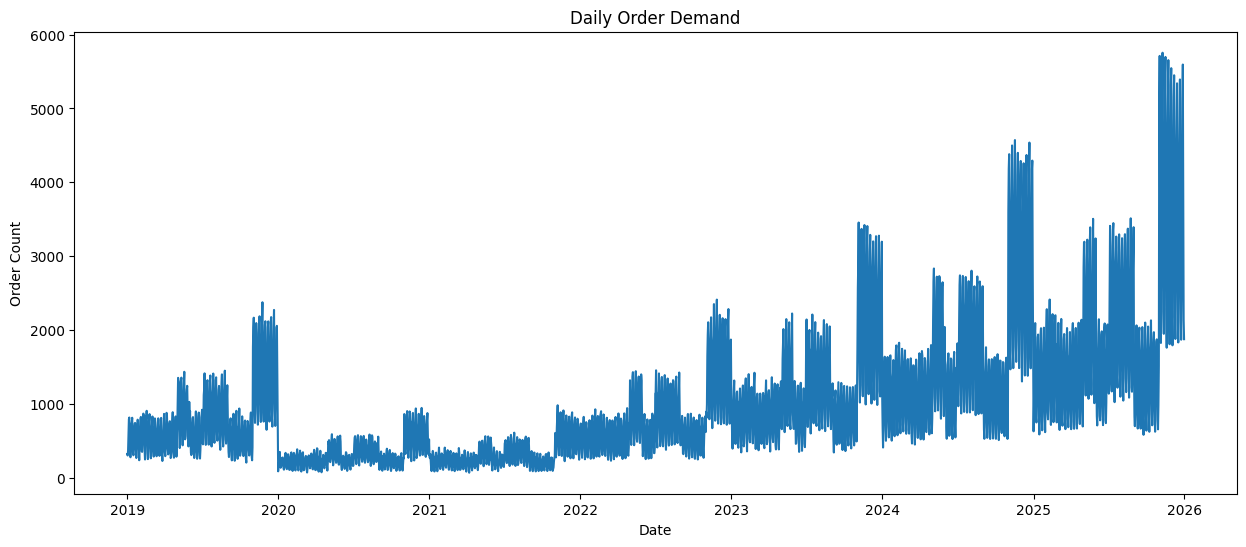

In [6]:
# =========================================================
# STEP 5 — VISUALIZE DAILY DEMAND
# =========================================================

plt.figure(figsize=(15,6))

plt.plot(
    daily_orders['date'],
    daily_orders['order_count']
)

plt.title("Daily Order Demand")

plt.xlabel("Date")

plt.ylabel("Order Count")

plt.show()

In [7]:
# =========================================================
# STEP 6 — SCALING
# =========================================================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    daily_orders[['order_count']]
)

print(scaled_data.shape)

(2555, 1)


In [8]:
# =========================================================
# STEP 7 — CREATE SEQUENCES
# =========================================================

def create_sequences(data, seq_length=30):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(
            data[i:i+seq_length]
        )

        y.append(
            data[i+seq_length]
        )

    return np.array(X), np.array(y)

In [9]:
# =========================================================
# STEP 8 — PREPARE LSTM DATA
# =========================================================

SEQ_LENGTH = 30

X, y = create_sequences(
    scaled_data,
    SEQ_LENGTH
)

print(X.shape)
print(y.shape)

(2525, 30, 1)
(2525, 1)


In [10]:
# =========================================================
# STEP 9 — TRAIN TEST SPLIT
# =========================================================

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(2020, 30, 1)
(505, 30, 1)


In [11]:
# =========================================================
# STEP 10 — BUILD LSTM MODEL
# =========================================================

model = Sequential()

# LSTM Layer 1
model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

# LSTM Layer 2
model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

# Dense Layers
model.add(Dense(32, activation='relu'))

model.add(Dense(1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# =========================================================
# STEP 11 — COMPILE MODEL
# =========================================================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [13]:
# =========================================================
# STEP 12 — EARLY STOPPING
# =========================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [14]:
# =========================================================
# STEP 13 — TRAIN MODEL
# =========================================================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 0.0063 - mae: 0.0568 - val_loss: 0.0267 - val_mae: 0.1282
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0053 - mae: 0.0529 - val_loss: 0.0315 - val_mae: 0.1323
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0051 - mae: 0.0520 - val_loss: 0.0260 - val_mae: 0.1262
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0046 - mae: 0.0480 - val_loss: 0.0246 - val_mae: 0.1174
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0045 - mae: 0.0477 - val_loss: 0.0240 - val_mae: 0.1185
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0042 - mae: 0.0464 - val_loss: 0.0251 - val_mae: 0.1230
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0049 - mae: 0.0506 - val_loss: 0.0261 - val_mae: 0.1263
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0045 - mae: 0.0483 - val_loss: 0.0247 - val_mae: 0.1213
Epoch 9/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.004

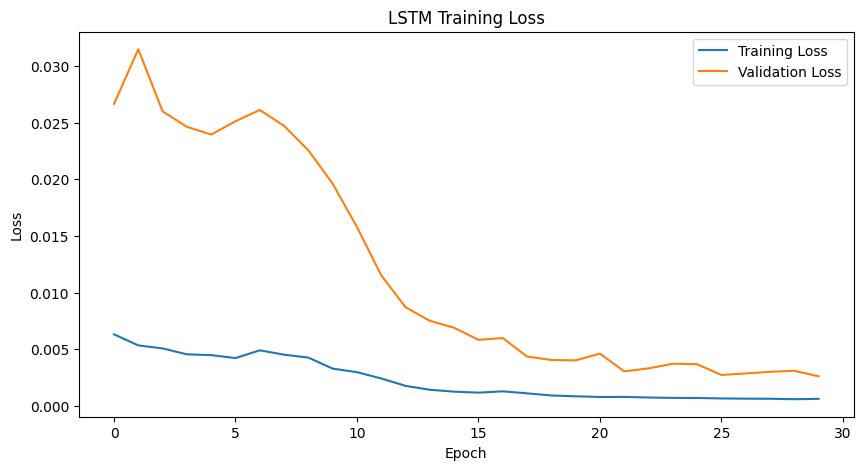

In [15]:
# =========================================================
# STEP 14 — TRAINING LOSS PLOT
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [16]:
# =========================================================
# STEP 15 — PREDICTIONS
# =========================================================

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y_test)

print(predictions[:5])

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
[[ 937.1618]
 [1429.6052]
 [2179.303 ]
 [2580.7556]
 [2752.3752]]


In [17]:
# =========================================================
# STEP 16 — EVALUATION METRICS
# =========================================================

mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

r2 = r2_score(actual, predictions)

print("MAE :", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE : 154.7057155495823
RMSE: 290.49100023396886
R2 Score: 0.9369362625169293


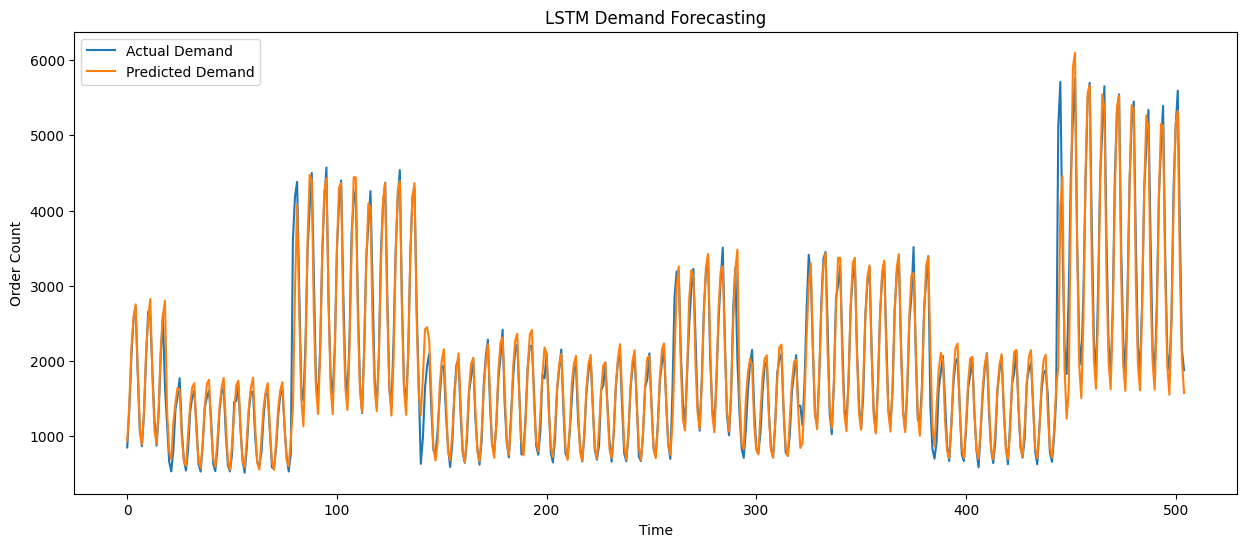

In [18]:
# =========================================================
# STEP 17 — VISUALIZE PREDICTIONS
# =========================================================

plt.figure(figsize=(15,6))

plt.plot(
    actual,
    label='Actual Demand'
)

plt.plot(
    predictions,
    label='Predicted Demand'
)

plt.title("LSTM Demand Forecasting")

plt.xlabel("Time")

plt.ylabel("Order Count")

plt.legend()

plt.show()

In [19]:
# =========================================================
# STEP 18 — FUTURE FORECASTING
# =========================================================

future_days = 30

last_sequence = X_test[-1]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):

    pred = model.predict(
        current_sequence.reshape(1, SEQ_LENGTH, 1),
        verbose=0
    )

    future_predictions.append(pred[0][0])

    current_sequence = np.append(
        current_sequence[1:],
        pred
    )

future_predictions = np.array(
    future_predictions
).reshape(-1,1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

print(future_predictions[:10])

[[1572.7179]
 [2406.3257]
 [3958.7808]
 [4939.83  ]
 [5225.    ]
 [3184.8193]
 [1819.0902]
 [1393.2683]
 [2174.64  ]
 [3599.4482]]


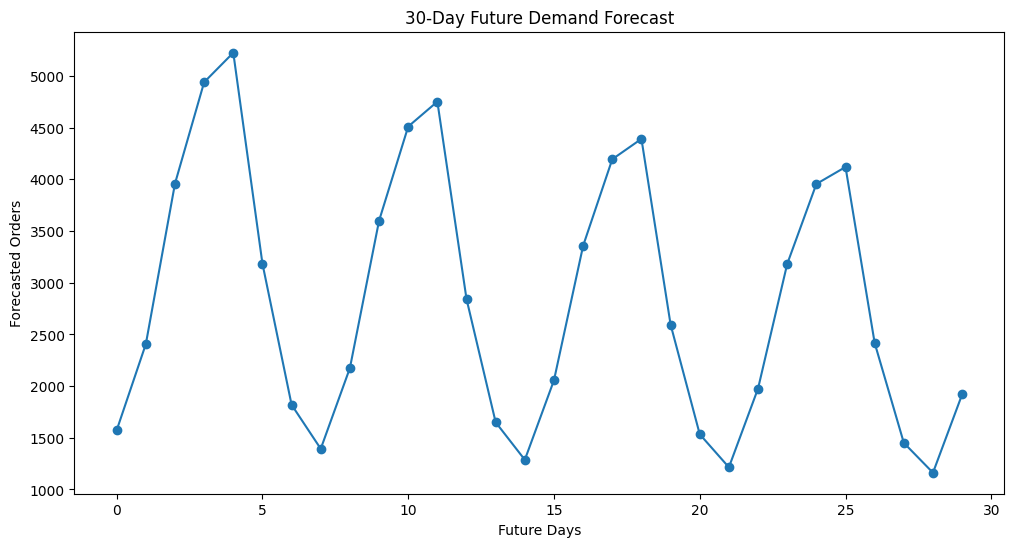

In [20]:
# =========================================================
# STEP 19 — PLOT FUTURE FORECAST
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    future_predictions,
    marker='o'
)

plt.title("30-Day Future Demand Forecast")

plt.xlabel("Future Days")

plt.ylabel("Forecasted Orders")

plt.show()

In [ ]:
# =========================================================
# STEP 20 — SAVE MODEL
# =========================================================

model.save(
    MODELS_DIR / "lstm_forecasting_model.h5"
)

print("LSTM Forecasting Model Saved Successfully")

LSTM Model Saved Successfully


In [22]:
# =========================================================
# STEP 22 — BUSINESS INSIGHTS
# =========================================================

print("""

===================================================

BUSINESS INSIGHTS

===================================================

1. Built Deep Learning Time-Series Forecasting System.

2. Used LSTM architecture for sequential demand learning.

3. Forecasted future order demand patterns.

4. Model can support:
   - Inventory planning
   - Demand forecasting
   - Warehouse optimization
   - Supply chain analytics

5. Learned:
   - Seasonal patterns
   - Sequential dependencies
   - Demand fluctuations

6. Generated future 30-day demand forecast.

7. Saved trained forecasting model for deployment.

===================================================

""")




BUSINESS INSIGHTS


1. Built Deep Learning Time-Series Forecasting System.

2. Used LSTM architecture for sequential demand learning.

3. Forecasted future order demand patterns.

4. Model can support:
   - Inventory planning
   - Demand forecasting
   - Warehouse optimization
   - Supply chain analytics

5. Learned:
   - Seasonal patterns
   - Sequential dependencies
   - Demand fluctuations

6. Generated future 30-day demand forecast.

7. Saved trained forecasting model for deployment.





In [23]:
# =========================================================
# STEP 23 — NOTEBOOK COMPLETION
# =========================================================

print("""

===================================================
13_lstm_forecasting.ipynb COMPLETED SUCCESSFULLY
===================================================

""")



13_lstm_forecasting.ipynb COMPLETED SUCCESSFULLY


